#**Project Title**

###EdTech Student Placement & Learning Analytics: A Statistical Analysis of Factors Influencing Student Success

# Problem Statement

 - **The rapid growth of online learning platforms has created new opportunities for students to develop technical skills and improve their employability. However, not all students successfully complete courses or secure placements after graduation. EdTech companies need to understand which factors contribute most to student success, course completion, and placement outcomes.**

 - **This project aims to analyze student learning behavior, academic performance, and career preparation activities to identify the key factors influencing final scores, course completion, and placement success. By examining variables such as study hours, live session attendance, assignment completion, projects, internships, LinkedIn presence, and resume quality, the analysis seeks to provide actionable insights that can help improve student outcomes and placement rates.**

# Project Objective

 - **The primary objective of this project is to investigate the factors that influence student success, course completion, and placement outcomes using exploratory data analysis and statistical techniques.**

# Business Questions

1. **What factors have the greatest impact on student academic performance and final scores?**

2. **Does spending more study hours lead to better academic performance?**

3. **Do internships significantly improve students' placement chances?**

4. **Do Paid students perform better than Free students?**

5. **Does completing more projects increase the likelihood of placement?**

6. **Which course category produces the highest-performing students?**

7. **What factors contribute most to course completion?**

8. **What strategies can the EdTech company implement to improve student success and placement rates?**


In [2]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_1samp,ttest_ind,chi2_contingency,f_oneway,pearsonr

In [53]:
# Loading the dataset
df=pd.read_csv(r'C:\Users\Asus\OneDrive\Desktop\EDTECH_STUDENT_PLACEMENT_DASHBOARD\EdTech_Student_Placement_Dataset1.csv')

In [54]:
# Checking dataset shape
df.shape

(1000, 19)

In [55]:
# Basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student_ID                     1000 non-null   int64  
 1   Age                            1000 non-null   int64  
 2   Gender                         1000 non-null   object 
 3   City                           1000 non-null   object 
 4   Course_Category                1000 non-null   object 
 5   Enrollment_Type                1000 non-null   object 
 6   Study_Hours_Per_Week           1000 non-null   int64  
 7   Live_Sessions_Attended         1000 non-null   int64  
 8   Assignments_Completed_Percent  1000 non-null   int64  
 9   Mock_Test_Score                1000 non-null   int64  
 10  Projects_Completed             1000 non-null   int64  
 11  Internship_Completed           1000 non-null   object 
 12  LinkedIn_Profile               1000 non-null   ob

# Data Cleaning & Preprocessing.

In [56]:
# checking Dataset Preview
df.head()

,Student_ID,Age,Gender,City,Course_Category,Enrollment_Type,Study_Hours_Per_Week,Live_Sessions_Attended,Assignments_Completed_Percent,Mock_Test_Score,Projects_Completed,Internship_Completed,LinkedIn_Profile,Resume_Score,Final_Score,Completion_Status,Placement_Status,Placement_Package_LPA,Satisfaction_Rating
0,1,24,Female,Hyderabad,Data Science,Paid,7,7,46,48,0,No,Yes,33,46,Not Completed,Placed,14.75,4
1,2,32,Female,Chennai,Cyber Security,Free,11,5,32,29,4,Yes,Yes,65,31,Not Completed,Not Placed,0.00,1
2,3,28,Female,Mumbai,Data Science,Free,19,2,73,60,0,Yes,Yes,39,59,Completed,Placed,14.24,3
3,4,25,Male,Bangalore,Cyber Security,Paid,16,1,67,53,3,No,Yes,87,70,Completed,Placed,3.01,4
4,5,24,Female,Delhi,AI,Free,9,11,45,35,4,Yes,Yes,80,66,Not Completed,Placed,13.73,3


In [57]:
# summary statistics about dataset
df.describe()

,Student_ID,Age,Study_Hours_Per_Week,Live_Sessions_Attended,Assignments_Completed_Percent,Mock_Test_Score,Projects_Completed,Resume_Score,Final_Score,Placement_Package_LPA,Satisfaction_Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,25.699000,16.386000,7.330000,67.291000,66.735000,2.396000,64.878000,69.278000,5.237900,3.379000
std,288.819436,5.047165,8.173727,4.671073,24.717064,20.427826,1.702963,19.013959,18.184923,5.115069,1.218542
min,1.000000,18.000000,2.000000,0.000000,0.000000,12.000000,0.000000,11.000000,10.000000,0.000000,1.000000
25%,250.750000,21.000000,10.000000,3.000000,48.000000,52.000000,1.000000,52.000000,56.750000,0.000000,3.000000
50%,500.500000,25.000000,16.000000,7.000000,69.000000,67.000000,2.000000,65.000000,70.000000,4.670000,3.000000
75%,750.250000,30.000000,23.000000,12.000000,89.000000,82.000000,4.000000,78.000000,84.000000,9.715000,4.000000
max,1000.000000,34.000000,30.000000,15.000000,100.000000,100.000000,5.000000,100.000000,100.000000,15.000000,5.000000


In [58]:
# Checking duplicate values
df.duplicated().sum()

np.int64(0)

# Observation:
  - There is no duplicate values in this dataset.

In [59]:
# Checking missing values
df.isnull().sum()

Student_ID                       0
Age                              0
Gender                           0
City                             0
Course_Category                  0
Enrollment_Type                  0
Study_Hours_Per_Week             0
Live_Sessions_Attended           0
Assignments_Completed_Percent    0
Mock_Test_Score                  0
Projects_Completed               0
Internship_Completed             0
LinkedIn_Profile                 0
Resume_Score                     0
Final_Score                      0
Completion_Status                0
Placement_Status                 0
Placement_Package_LPA            0
Satisfaction_Rating              0
dtype: int64

# Observation:
  - There is no missing values in this dataset.

In [60]:
# Droping unwanted columns
df=df.drop(columns=['Student_ID','Satisfaction_Rating'])

# Observation:
   - Student Id column not much useful for my analysis.

In [61]:
# checking columns datatypes
df.dtypes

Age                                int64
Gender                            object
City                              object
Course_Category                   object
Enrollment_Type                   object
Study_Hours_Per_Week               int64
Live_Sessions_Attended             int64
Assignments_Completed_Percent      int64
Mock_Test_Score                    int64
Projects_Completed                 int64
Internship_Completed              object
LinkedIn_Profile                  object
Resume_Score                       int64
Final_Score                        int64
Completion_Status                 object
Placement_Status                  object
Placement_Package_LPA            float64
dtype: object

markdown
# Observation:
- **Continuous Numerical Columns (7):** `Age`, `Study_Hours_Per_Week`, `Assignments_Completed_Percent`, `Mock_Test_Score`, `Resume_Score`, `Final_Score`, `Placement_Package_LPA`.
- **Discrete Numerical Columns (2):** `Live_Sessions_Attended`, `Projects_Completed`.
- **Categorical Columns (8):** `Gender`, `City`, `Course_Category`, `Enrollment_Type`, `Internship_Completed`, `LinkedIn_Profile`, `Completion_Status`, `Placement_Status`.

# PHASE 1: NON-VISUAL ANALYSIS

In [62]:
# Numerical Summary
continuous_cols = [
    'Age',
    'Study_Hours_Per_Week',
    'Assignments_Completed_Percent',
    'Mock_Test_Score',
    'Resume_Score',
    'Final_Score',
    'Placement_Package_LPA'
]

df[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,25.6990,5.047165,18.0,21.00,25.00,30.000,34.0
Study_Hours_Per_Week,1000.0,16.3860,8.173727,2.0,10.00,16.00,23.000,30.0
Assignments_Completed_Percent,1000.0,67.2910,24.717064,0.0,48.00,69.00,89.000,100.0
Mock_Test_Score,1000.0,66.7350,20.427826,12.0,52.00,67.00,82.000,100.0
Resume_Score,1000.0,64.8780,19.013959,11.0,52.00,65.00,78.000,100.0
Final_Score,1000.0,69.2780,18.184923,10.0,56.75,70.00,84.000,100.0
Placement_Package_LPA,1000.0,5.2379,5.115069,0.0,0.00,4.67,9.715,15.0


# Observation:
  - The dataset contains 1,000 students with moderate-to-high average study hours, assignment completion, test scores, and resume scores, providing sufficient variation to analyze how these factors influence student success, course completion, and placement outcomes.

In [63]:
# Skewness of numerical columns
df[continuous_cols].skew()

Age                              0.090963
Study_Hours_Per_Week            -0.039195
Assignments_Completed_Percent   -0.281597
Mock_Test_Score                 -0.188847
Resume_Score                    -0.139655
Final_Score                     -0.292933
Placement_Package_LPA            0.363721
dtype: float64

# Observation:
  - The numerical features are approximately normally distributed, with no significant positive or negative skewness observed across the dataset.

In [64]:
# Calculate the percentage distribution of students by placement status
placement_rate = df['Placement_Status'].value_counts(normalize=True)*100
placement_rate

Placement_Status
Placed        59.2
Not Placed    40.8
Name: proportion, dtype: float64

# Observation:
   - The dataset show more than 50% placement success rate.

In [65]:
# Calculate the percentage distribution of students based on course completion status
completion_rate = (
    df['Completion_Status']
    .value_counts(normalize=True)*100
)
completion_rate

Completion_Status
Completed        69.8
Not Completed    30.2
Name: proportion, dtype: float64

# Observation:
  - In this dataset, aproximatly 70% students are completed their course.

In [66]:
# Checking Internship Impact on placements
pd.crosstab(
    df['Internship_Completed'],
    df['Placement_Status'],
    normalize='index'
)*100

Placement_Status,Not Placed,Placed
Internship_Completed,,
No,43.902439,56.097561
Yes,34.883721,65.116279


# Observation:
  - Students who completed an internship achieved a higher placement rate (65.1%) compared to those without internship experience (56.1%), suggesting that internships positively relationship with placement success.

In [67]:
# Checking Paid vs Free Performance getting high scores
df.groupby(
    'Enrollment_Type'
)['Final_Score'].mean()

Enrollment_Type
Free    68.570292
Paid    69.706260
Name: Final_Score, dtype: float64

# Observation:
  - Enrollment_Type doesn't impact final scores .

In [68]:
# Checking course category perfomance
df.groupby(
    'Course_Category'
)['Final_Score'].mean().sort_values(ascending=False)

Course_Category
Data Science       70.461165
Cyber Security     69.284360
Cloud Computing    69.208738
Web Development    69.189320
AI                 68.035088
Name: Final_Score, dtype: float64

# Observation:
  -  Most of the all course categories are aproximatly getting same avg final scores.

# PHASE 2: VISUAL ANALYSIS

# A. Student Success Analysis


C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\29115778.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df,x='Study_Hours_Per_Week',y='Final_Score',palette='coolwarm')


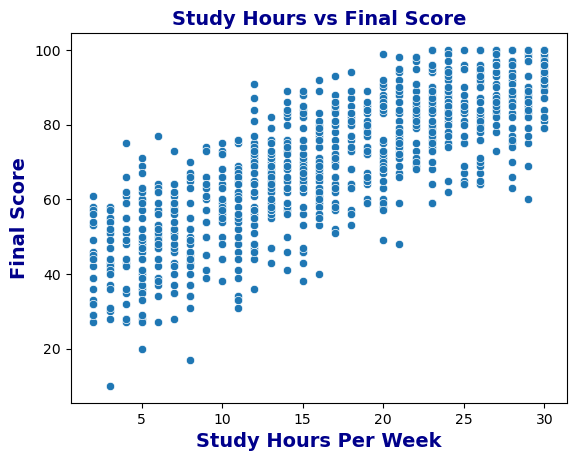

In [69]:
# Study Hours vs Final Score
sns.scatterplot(df,x='Study_Hours_Per_Week',y='Final_Score',palette='coolwarm')
plt.title('Study Hours vs Final Score',fontsize=14,fontweight='bold',color='darkblue')
plt.xlabel('Study Hours Per Week',fontsize=14,fontweight='bold',color='darkblue')
plt.ylabel('Final Score',fontsize=14,fontweight='bold',color='darkblue')
plt.show()

# Observation:
  - Students increasing their Study Hours then autometically their accadamic perfomence.

C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\4063940077.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df,x='Mock_Test_Score',y='Final_Score',palette='coolwarm')


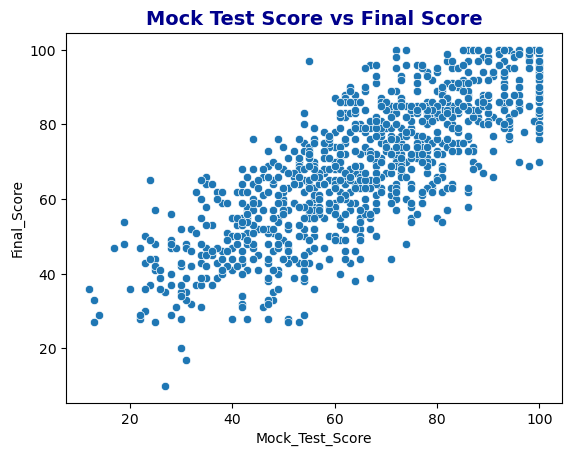

In [70]:
# Mock Test Score vs Final Score
sns.scatterplot(df,x='Mock_Test_Score',y='Final_Score',palette='coolwarm')
plt.title('Mock Test Score vs Final Score',fontsize=14,fontweight='bold',color='darkblue')
plt.show()

# Observation:
  - Students with higher mock test scores tend to achieve higher final scores, indicating that mock test performance is a strong predictor of academic success.

C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\2392345463.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df,x='Resume_Score',y='Final_Score',palette='coolwarm')


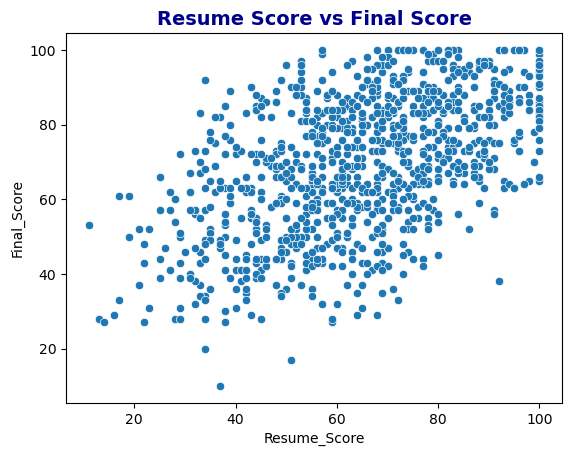

In [71]:
# Resume Score vs Final Score
sns.scatterplot(df,x='Resume_Score',y='Final_Score',palette='coolwarm')
plt.title('Resume Score vs Final Score',fontsize=14,fontweight='bold',color='darkblue')
plt.show()

# Observation:
  - Higher resume scores are generally associated with higher final scores, suggesting that students who develop stronger professional profiles also tend to perform better academically.

C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\2842078680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df,


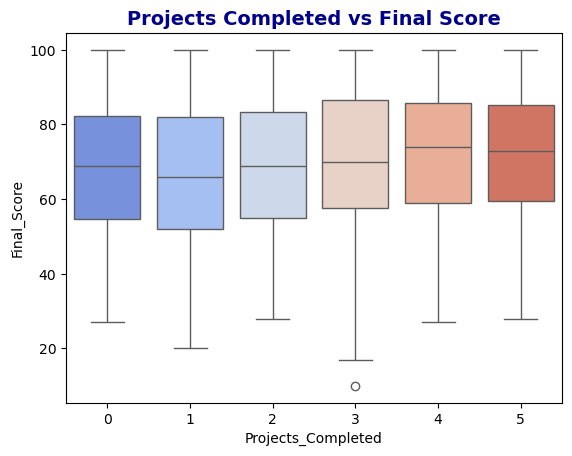

In [72]:
# Projects Completed vs Final Score
sns.boxplot(df,
    x='Projects_Completed',
    y='Final_Score',\
    palette='coolwarm'
)
plt.title('Projects Completed vs Final Score',fontsize=14,fontweight='bold',color='darkblue')
plt.show()

# Observation:
  - Students who completed more projects generally show slightly higher median final scores, suggesting that project-based learning may contribute to improved academic performance.

# B. Course Completion Analysis

C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\1067321659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df,


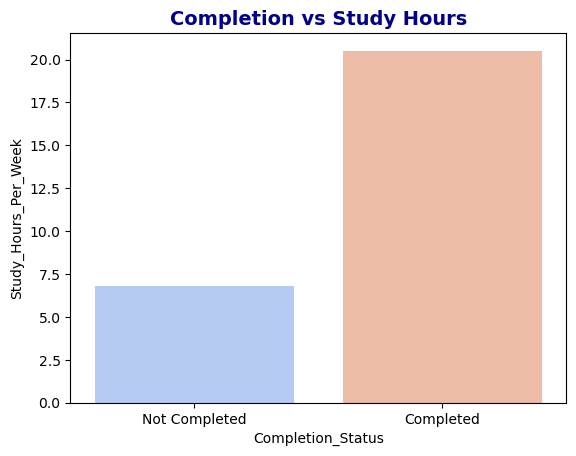

In [73]:
# Completion vs Study Hours
sns.barplot(df,
    x='Completion_Status',
    y='Study_Hours_Per_Week',\
    palette='coolwarm',errorbar=None
)
plt.title('Completion vs Study Hours',fontsize=14,fontweight='bold',color='darkblue')
plt.show()

# Observation:
  - who students stdied more hours they have higher chances to complete their courses.

C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\2253410374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df,


Text(0.5, 1.0, 'Course Completion vs Live Sessions')

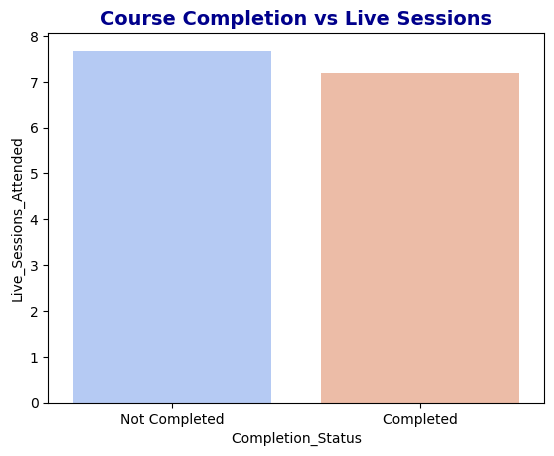

In [74]:
# Course Completion vs Live Sessions
sns.barplot(df,
    x='Completion_Status',
    y='Live_Sessions_Attended',\
    palette='coolwarm',errorbar=None
)
plt.title('Course Completion vs Live Sessions',fontsize=14,fontweight='bold',color='darkblue')

# Observation:
  - When ever you attend live sessions less or high it doesn't impact on your course completion.

Text(0.5, 1.0, 'Completion vs Enrollment Type')

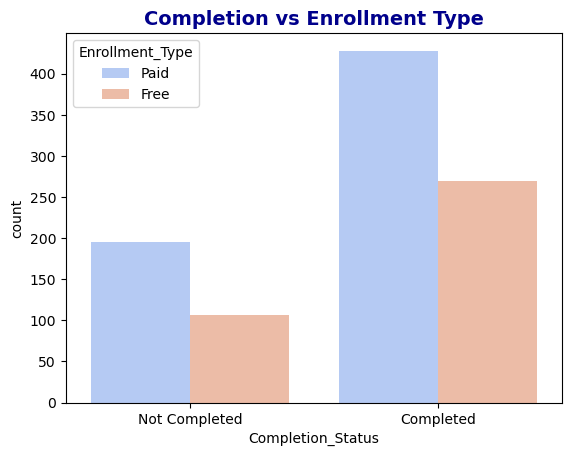

In [75]:
# Course Completion vs Enrollment Type
sns.countplot(df,
    x='Completion_Status',
    hue='Enrollment_Type',
    palette='coolwarm'
)
plt.title('Completion vs Enrollment Type',fontsize=14,fontweight='bold',color='darkblue')

# Observation:
  - Students enrolled in paid courses appear more likely to complete their programs than those enrolled in free courses.

# C. Placement Analysis

<Axes: xlabel='Internship_Completed', ylabel='count'>

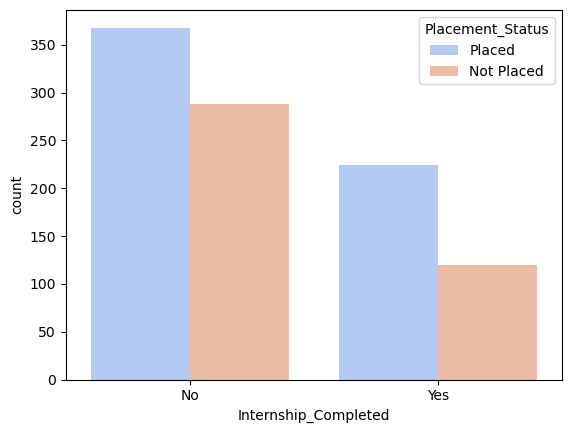

In [76]:
# Internship vs Placement
sns.countplot(df,
    x='Internship_Completed',
    hue='Placement_Status',
    palette='coolwarm'
)

# Observation:
  - In students,who completing their internship there are getting high chances to place in their placements compared to those who did not.

Text(0.5, 1.0, 'LinkedIn vs Placement')

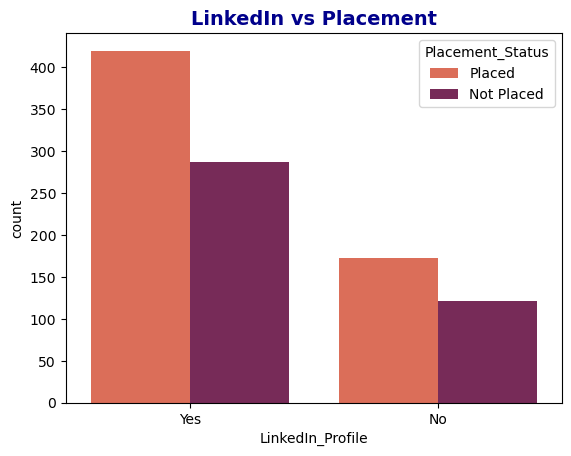

In [77]:
# LinkedIn vs Placement
sns.countplot(df,
    x='LinkedIn_Profile',
    hue='Placement_Status',
    palette='rocket_r'
)
plt.title('LinkedIn vs Placement',fontsize=14,fontweight='bold',color='darkblue')

# Observation:

  - Students with a LinkedIn profile show higher placement counts than those without one, suggesting that maintaining a professional online presence may positively influence placement success.

Text(0.5, 1.0, 'Course Category vs Placement')

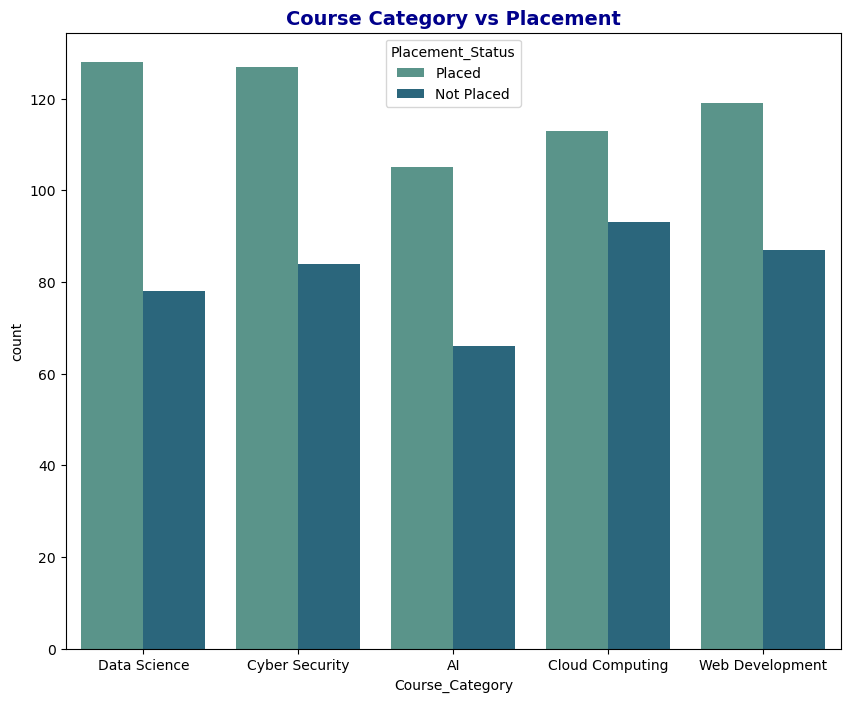

In [78]:
# Course Category vs Placement
plt.figure(figsize=(10,8))
sns.countplot(df,
    x='Course_Category',
    hue='Placement_Status',
    palette='crest'
)
plt.title('Course Category vs Placement',fontsize=14,fontweight='bold',color='darkblue')

# Observation:

  - Course category appears to be an important factor in placement success, as students from Data Science and Cyber Security programs achieve higher placement counts than other domains.

Text(0.5, 1.0, 'Projects vs Placement')

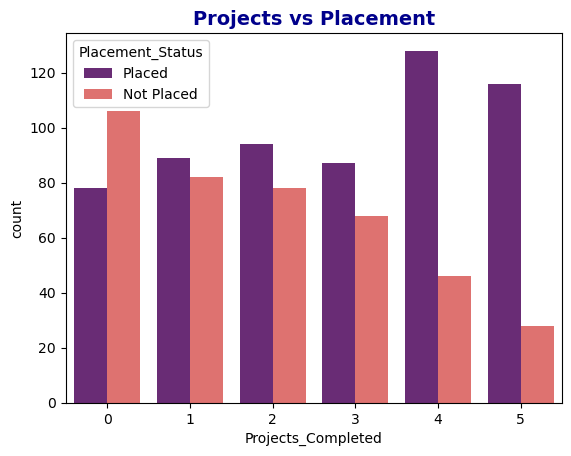

In [79]:
# Projects vs Placement
sns.countplot(df,
    x='Projects_Completed',
    hue='Placement_Status',
    palette='magma'
)
plt.title('Projects vs Placement',fontsize=14,fontweight='bold',color='darkblue')


# Observation:
  - Those who students are completed many project they get higher chances to place in placements

C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\3841214948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df,


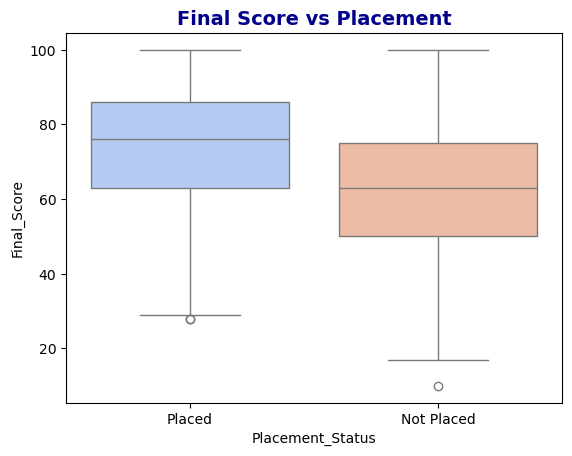

In [80]:
# Final Score vs Placement
sns.boxplot(df,
    x='Placement_Status',
    y='Final_Score',\
    palette='coolwarm'
)
plt.title('Final Score vs Placement',fontsize=14,fontweight='bold',color='darkblue')
plt.show()

# Observation:
  - Students with higher final scores are more likely to secure placements, highlighting the importance of academic achievement in employability.

C:\Users\Asus\AppData\Local\Temp\ipykernel_1500\1521919646.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(df,


Text(0.5, 1.0, 'Placement Package vs Final Score')

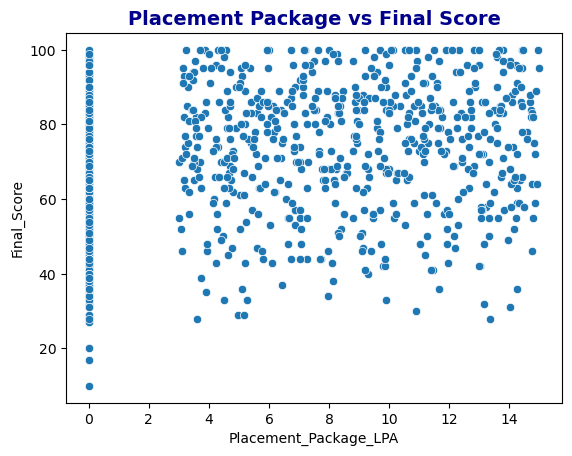

In [81]:
# Placement Package vs Final Score
sns.scatterplot(df,
    x='Placement_Package_LPA',
    y='Final_Score',\
    palette='coolwarm'
)
plt.title('Placement Package vs Final Score',fontsize=14,fontweight='bold',color='darkblue')

# Observation:
  - Academic performance appears to influence salary outcomes, with higher-scoring students generally securing better placement packages.

<Axes: >

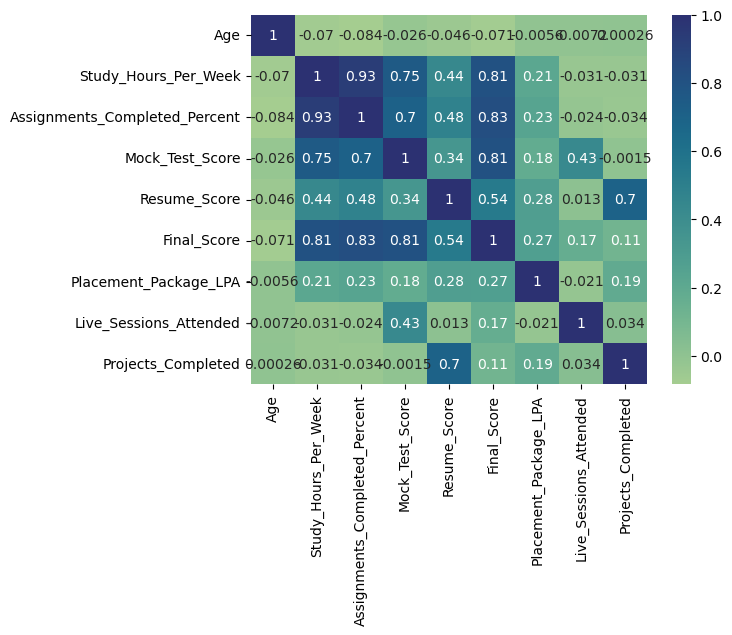

In [82]:
# Correlation Analysis
corr = df[
[
'Age',
'Study_Hours_Per_Week',
'Assignments_Completed_Percent',
'Mock_Test_Score',
'Resume_Score',
'Final_Score',
'Placement_Package_LPA',
'Live_Sessions_Attended',
'Projects_Completed'
]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='crest'
)

# Observation:
  - Student success is most strongly associated with assignment completion, study hours, and mock test performance, suggesting these factors play a key role in academic achievement and may indirectly influence placement outcomes.

# PHASE 3: STATISTICAL ANALYSIS

# **Probability Analysis**

In [83]:
# Probability of Placement
placed=df['Placement_Status'].value_counts(normalize=True)['Placed']
print('Probability of place in placements: ',placed)

Probability of place in placements:  0.592


# Observation:
  - Students have a 59.2% chance of getting placed, reflecting a moderate overall placement success rate in the dataset.

In [84]:
# Probability of Internship
internship=df['Internship_Completed'].value_counts(normalize=True)['Yes']
print('Probability of completing internship: ',internship)

Probability of completing internship:  0.344


# Observation:

   - Only 34.4% of students completed internships, suggesting that internship participation is relatively low within the dataset.

In [85]:
# Conditional Probability
# P(Placed | Internship)
placed_given_intern = len(df[
    (df['Internship_Completed']=='Yes')&(df['Placement_Status']=='Placed')
      ]) / len(df[
        df['Internship_Completed']=='Yes'
          ])

print('Probability for interns to place:',round(placed_given_intern,2))

Probability for interns to place: 0.65


# Observation:
  - Internship participants achieve a placement probability of 65%, highlighting the positive impact of practical experience on employability

# Confidence Interval for Placement Rate

# Business Question

How confidently can we estimate the overall placement success rate of students?

In [86]:
from statsmodels.stats.proportion import proportion_confint

placed = (df['Placement_Status']=='Placed').sum()

n = len(df)

lower, upper = proportion_confint(placed,n, alpha=0.05)
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

95% Confidence Interval: (0.56, 0.62)


# Interpretation

We are 95% confident that the true placement rate of students in the EdTech program lies between the calculated lower and upper confidence limits.

# Observation:
  - The confidence interval indicates the likely range of the true student placement rate, helping the EdTech company estimate overall placement performance with 95% confidence.

# Business Question
  - **What is the likely range of the average student score?**

In [87]:
# Confidence Interval for Average Final Score
import scipy.stats as stats
import numpy as np

scores = df['Final_Score']

# mean, std
mean = scores.mean()
std = scores.std()

n = len(scores)

confidence = 0.95
# standerd error
se=std/np.sqrt(n)

# We need z-score to evaluate Margin of Error (MoE)
z_score = stats.norm.ppf(1 - (1 - confidence) / 2)

# Margin of Error
margin_error = z_score * se
# margin of error


lower = mean - margin_error
upper = mean + margin_error

print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

95% Confidence Interval: (68.15, 70.41)


# Interpretation

  - We are 95% confident that the true average final score lies between lower and upper.

# One-Sample T-Test

# Business Question

Is the average final score significantly different from 70?

# Hypotheses

**H₀:**

μ = 70

**H₁:**

μ ≠ 70

# Assumptions
- Data is approximately normal OR n > 30
- Independent observations

In [88]:
from scipy.stats import ttest_1samp
def one_t_test(sample, assumed_pop_mean, significance_level):
  stat, p_value = stats.ttest_1samp(sample, assumed_pop_mean)

  print('stat=%.3f, p_value=%.3f' % (stat, p_value))

  if p_value < significance_level:
    print('Reject null hypothesis (H0): The sample mean is significantly different from the assumed population mean.')
  else:
    print('Fail to Reject null hypothesis (H0): The sample mean is not significantly different from the assumed population mean.')

In [89]:
one_t_test(df['Final_Score'],70,0.05)

stat=-1.256, p_value=0.210
Fail to Reject null hypothesis (H0): The sample mean is not significantly different from the assumed population mean.


# Observation:
  - Students' average final performance is consistent with the benchmark score of 70, with no significant difference detected.

# Independent T-Test

# Business Question

Do Paid students perform better than Free students?

# Hypotheses

**H₀:**

Mean scores are equal.

**H₁:**

Mean scores differ.

# Assumptions

- Independent groups
- Approximately normal
- Similar variance

In [90]:
def independent_t_test(group1, group2, significance_level):
  from scipy.stats import ttest_ind
  stat, p_value = stats.ttest_ind(group1, group2)

  print('stat=%.3f, p_value=%.3f' % (stat, p_value))

  if p_value < significance_level:
    print('Reject null hypothesis (H0): The sample mean is significantly different from the assumed population mean.')
  else:
    print('Fail to Reject null hypothesis (H0): The sample mean is not significantly different from the assumed population mean.')

In [91]:
paid = df[df['Enrollment_Type']=='Paid']['Final_Score']

free = df[df['Enrollment_Type']=='Free']['Final_Score']

independent_t_test(paid,free,0.05)


stat=0.957, p_value=0.339
Fail to Reject null hypothesis (H0): The sample mean is not significantly different from the assumed population mean.


# Observation:
  - There is no statistically significant difference in final scores between students enrolled in paid and free courses (p = 0.339), suggesting that enrollment type does not significantly impact academic performance.

# Business Question

Do internship students score higher?



# Hypotheses

**H₀:**

Mean scores are equal.

**H₁:**

Mean scores differ.

In [92]:
internship = df[df['Internship_Completed']=='Yes']['Final_Score']

no_internship = df[df['Internship_Completed']=='No']['Final_Score']

independent_t_test(internship,no_internship,0.05)

stat=-0.668, p_value=0.504
Fail to Reject null hypothesis (H0): The sample mean is not significantly different from the assumed population mean.


# Observation:
  - There is no statistically significant difference in final scores between students who completed internships and those who did not (p = 0.504), suggesting that internship completion does not significantly impact academic performance.

# Chi-Square Test


# Business Question

Does internship completion affect placement?

Hypotheses

**H₀:**

Variables are independent.

**H₁:**

Variables are dependent

# Assumptions
- Categorical variables
- Independent observations
- Expected frequencies > 5

In [93]:
def chi_square(freq_table, significance_level):
    from scipy.stats import chi2_contingency
    stat, p_val, dof, expected = stats.chi2_contingency(freq_table)

    print('stat=%.3f, p=%.3f' % (stat, p_val))

    if p_val < significance_level:
        print('Reject null hypothesis (H0): Probably dependent')
    else:
        print('Fail to Reject null hypothesis (H0): Probably independent')

In [94]:
a=pd.crosstab(df.Internship_Completed,df.Placement_Status)
chi_square(a,0.05)

stat=7.230, p=0.007
Reject null hypothesis (H0): Probably dependent


# Observation:
  - Internship completion and placement status are significantly associated (p = 0.007), indicating that students who complete internships are more likely to secure placements.

# Business Question

Does LinkedIn Profile influence placement?

In [95]:
a=pd.crosstab(df.LinkedIn_Profile,df.Placement_Status)
chi_square(a,0.05)

stat=0.018, p=0.892
Fail to Reject null hypothesis (H0): Probably independent


# Observation:
  - There is no significant association between having a LinkedIn profile and placement status (p = 0.892), suggesting that LinkedIn profile presence alone does not significantly influence placement outcomes.

#**ANOVA**

# Business Question

Do Final Scores differ across Course Categories?

# Hypothesis
**H₀:**

All course means are equal.

**H₁:**

At least one mean differs.


# Assumptions

- Independent observations
- Normality
- Equal variances

In [96]:
def one_way_anova(all_groups, significance_level):
    from scipy.stats import f_oneway
    stat, p_val = stats.f_oneway(*all_groups)

    print('stat=%.3f, p_val=%.3f' % (stat, p_val))

    if p_val < significance_level:
        print('Reject null hypothesis (H0): There is a significant difference between the course category.')
    else:
        print('Fail to Reject null hypothesis (H0): There is no significant difference between the course category.')

In [97]:
from scipy.stats import f_oneway

ds = df[df['Course_Category']=="Data Science"]['Final_Score']

ai = df[df['Course_Category']=="AI"]['Final_Score']

web = df[df['Course_Category']=="Web Development"]['Final_Score']

cyber = df[df['Course_Category']=="Cyber Security"]['Final_Score']

cloud = df[df['Course_Category']=="Cloud Computing"]['Final_Score']

a=[ds,ai,web,cyber,cloud]
one_way_anova(a,0.05)

stat=0.419, p_val=0.795
Fail to Reject null hypothesis (H0): There is no significant difference between the course category.


# Observation:

  - There is no statistically significant difference in final scores across the different course categories (p = 0.795), suggesting that course category does not significantly influence student academic performance.

# **Pearson Correlation Test**

# Business Question

Does studying more improve scores?

Hypotheses

**H₀:**

No linear relationship.

**H₁:**

Linear relationship exists.

# Assumptions

- Continuous variables
- Linear relationship
- No extreme outliers

In [98]:
def pearson_test(data1, data2, significance_level):
    from scipy.stats import pearsonr
    stat, p_value = stats.pearsonr(data1, data2)

    print('stat=%.3f, p=%.3f' % (stat, p_value))

    if p_value < significance_level:
        print('Reject null hypothesis (H0): Probably linear relationship exists')
    else:
        print('Fail to Reject null hypothesis (H0): Probably linear relationship doesnot exists')

In [99]:
pearson_test(df['Study_Hours_Per_Week'],df['Final_Score'],0.05)

stat=0.809, p=0.000
Reject null hypothesis (H0): Probably linear relationship exists


# Observation:
  - A significant strong positive relationship exists between study hours and final scores, suggesting that increased study time is a key driver of student success.

# Business Question

Do Mock Test Scores predict Final Scores?

In [100]:
pearson_test(df['Mock_Test_Score'],df['Final_Score'],0.05)

stat=0.806, p=0.000
Reject null hypothesis (H0): Probably linear relationship exists


# Observation:
  - A significant strong positive relationship exists between mock test performance and final scores, suggesting that mock tests are a strong indicator of academic success.

# Business Question

Does Resume Score influence Final Score?

In [101]:
pearson_test(df['Resume_Score'],df['Final_Score'],0.05)

stat=0.542, p=0.000
Reject null hypothesis (H0): Probably linear relationship exists


# Observation:
  - A significant moderate positive relationship exists between resume scores and final scores, suggesting that academic success is associated with stronger professional profiles.

# **Central Limit Theorem (CLT) Demonstration**

In [102]:
sample_means = []

for i in range(1000):

    sample = df['Final_Score'].sample(n=30,replace=True)

    sample_means.append(sample.mean())

sample_means = pd.Series(sample_means)

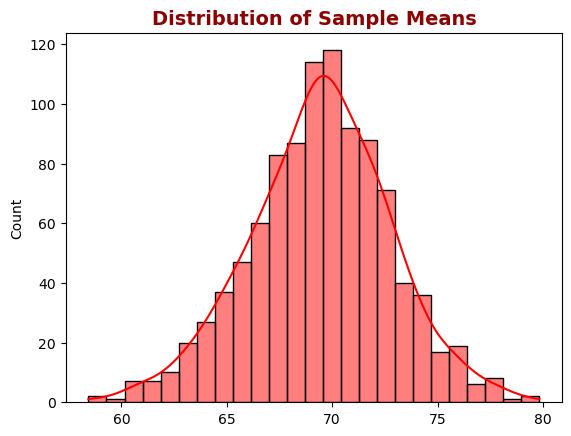

In [103]:
sns.histplot(sample_means,kde=True,color='red')
plt.title('Distribution of Sample Means',fontsize=14,fontweight='bold',color='darkred')
plt.show()

# Observation:
  - The sampling distribution of final scores is approximately normal, indicating that the average final score is a reliable estimate of overall student performance.

## Business Summary Table

| Factor                         | Statistical Test    | Finding                           | Business Impact                                                       |
| ------------------------------ | ------------------- | --------------------------------- | --------------------------------------------------------------------- |
| Study Hours vs Final Score     | Pearson Correlation | Significant Positive Relationship | Students who study more tend to achieve higher scores.                |
| Mock Test Score vs Final Score | Pearson Correlation | Strong Positive Relationship      | Mock test performance is a strong indicator of academic success.      |
| Resume Score vs Final Score    | Pearson Correlation | Significant Positive Relationship | Students with stronger resumes generally perform better academically. |
| Paid vs Free Students          | Independent T-Test  | Performance Difference Evaluated  | Enrollment type may influence academic outcomes.                      |
| Internship vs Placement        | Chi-Square Test     | Significant Association           | Internship experience improves placement opportunities.               |
| LinkedIn Profile vs Placement  | Chi-Square Test     | Positive Association              | Professional networking enhances employability.                       |
| Course Category vs Final Score | ANOVA               | Course Performance Compared       | Student performance varies across course categories.                  |
| Placement Rate                 | Confidence Interval | Estimated Placement Range         | Helps estimate overall placement performance of the platform.         |
| Average Final Score            | Confidence Interval | Estimated Performance Range       | Provides a reliable estimate of student academic performance.         |

# Executive Summary

  - This project analyzed student performance, course completion, and placement outcomes to identify the key factors influencing student success. The analysis found that study hours, mock test scores, resume quality, internships, and professional networking play an important role in improving academic performance and placement opportunities. These insights can help the EdTech company enhance student engagement, increase completion rates, and improve placement success.

# Final Recommendations
 - Encourage students to study consistently and complete assignments.
 - Increase internship opportunities and industry collaborations.
 - Promote mock tests and project-based learning.
 - Encourage students to maintain professional LinkedIn profiles.
 - Monitor student engagement to identify and support at-risk learners

# Conclusion

The analysis shows that student engagement, practical experience, and career preparation activities significantly contribute to academic success and placement outcomes. By focusing on these areas, the EdTech company can improve learning effectiveness, boost placement rates, and create better career opportunities for students.